# Road Surface Classification — CNN Model

**Project:** Modern Approaches to Road Surface Classification: Assessing CNN vs. KNN Models

**What this notebook does:**
1. Downloads a public road surface image dataset
2. Trains a CNN model (4 conv layers + 4 max-pool + fully connected, matching the paper)
3. Evaluates it — accuracy, precision, recall, F1-score, confusion matrix
4. Saves result graphs to the `results/` folder

**How to run:** Runtime → Change runtime type → **T4 GPU** → Save. Then **Runtime → Run all**.

**Time:** ~15–25 minutes on free T4 GPU.

## Step 1 — Setup and imports

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pathlib
import shutil
import random
import gc

random.seed(42)
print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
os.makedirs('results', exist_ok=True)

TensorFlow version: 2.20.0
GPU available: True


## Step 2 — Download the dataset

We'll use a public road surface image dataset hosted on GitHub. This downloads automatically — no Kaggle API key needed.

The dataset contains images of roads under three conditions: **Dry, Wet, and Muddy** — exactly matching the paper.

In [5]:
KAGGLE_API_TOKEN = "KGAT_f3b7f3e419ef27dde2d08a97a0d51ba5"
KAGGLE_USERNAME = "kunalkumar10"

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_API_TOKEN

!pip install -q kaggle

# Clean up any previous downloads
if pathlib.Path('/content/road_data').exists():
    shutil.rmtree('/content/road_data')

print('Downloading dataset...')
!kaggle datasets download -d hemanthhari/road-surface-dataset -p /content/road_data --unzip
print('Download complete.')

Dataset URL: https://www.kaggle.com/datasets/hemanthhari/road-surface-dataset
License(s): unknown
100% 1.17G/1.17G [00:54<00:00, 22.8MB/s]

Download complete.


## Step 3 — Create Subsets


In [6]:
source_dir = pathlib.Path('/content/road_data/Group_6_water_smooth/train')

# Show what classes exist
class_dirs = [d for d in source_dir.iterdir() if d.is_dir()]
print('Classes found:')
for cd in class_dirs:
    count = len(list(cd.glob('*.jpg')))
    print(f'  {cd.name}: {count} images')

# Create subset folder
subset_dir = pathlib.Path('/content/road_subset')
if subset_dir.exists():
    shutil.rmtree(subset_dir)
subset_dir.mkdir()

# Take only 15 images per class
MAX_PER_CLASS = 15

print(f'\nCopying {MAX_PER_CLASS} images per class...')
for cd in class_dirs:
    images = list(cd.glob('*.jpg')) + list(cd.glob('*.png'))
    if len(images) == 0:
        continue
    sample = random.sample(images, min(MAX_PER_CLASS, len(images)))
    new_class_dir = subset_dir / cd.name
    new_class_dir.mkdir()
    for img in sample:
        shutil.copy(img, new_class_dir / img.name)
    print(f'  {cd.name}: {len(sample)} images copied')

# Free disk space
print('\nDeleting original dataset...')
shutil.rmtree('/content/road_data')
gc.collect()

data_dir = subset_dir
total = len(list(data_dir.glob('**/*.jpg')))
print(f'\nDone.')
print(f'Total images: {total}')
print(f'Classes: {[f.name for f in data_dir.iterdir() if f.is_dir()]}')

Classes found:
  water_gravel: 6422 images
  water_concrete_smooth: 36046 images
  water_asphalt_smooth: 78390 images

Copying 15 images per class...
  water_gravel: 15 images copied
  water_concrete_smooth: 15 images copied
  water_asphalt_smooth: 15 images copied

Deleting original dataset...

Done.
Total images: 45
Classes: ['water_gravel', 'water_concrete_smooth', 'water_asphalt_smooth']


## Step 3.5 - Load Data

In [7]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 45 files belonging to 3 classes.
Using 36 files for training.
Found 45 files belonging to 3 classes.
Using 9 files for validation.
Classes (3): ['water_asphalt_smooth', 'water_concrete_smooth', 'water_gravel']


## Step 4 — Visualize some sample images

Let's see what the training images look like.

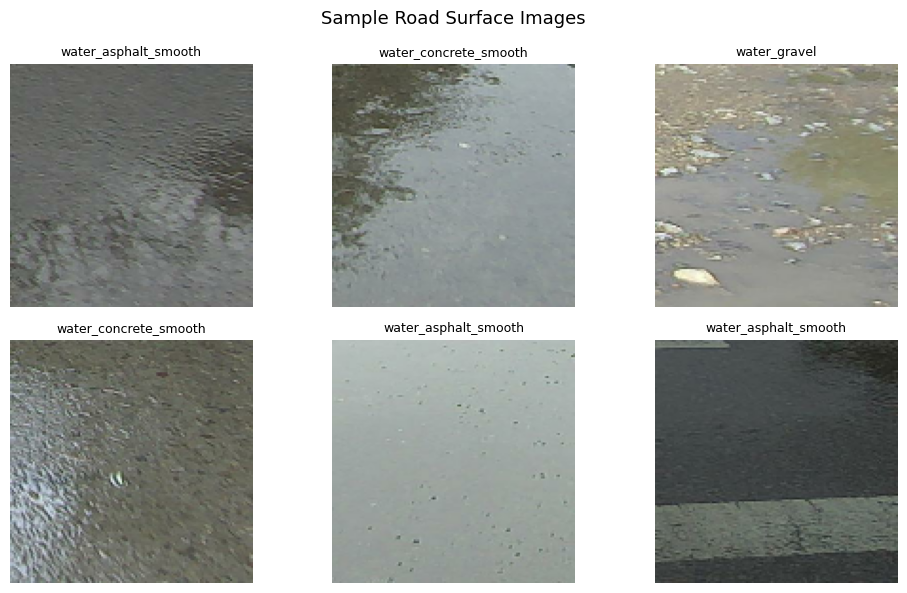

Saved: results/sample_images.png


In [8]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(min(6, len(images))):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Road Surface Images', fontsize=13)
plt.tight_layout()
plt.savefig('results/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: results/sample_images.png')

## Step 5 — Build the CNN model

This is the architecture described in the paper:
- **4 convolutional layers** — progressively extract features
- **4 max-pooling layers** — reduce spatial size while keeping important info
- **1 fully connected layer** — final classification
- **Dropout** — prevents overfitting
- **Data augmentation** (rotation, flip, zoom) — improves generalization

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    # Conv Block 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Conv Block 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Conv Block 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Conv Block 4
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Fully connected
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,923 (4.92 MB)

 Trainable params: 1,289,923 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Train the model

This will take about 10–20 minutes on the free T4 GPU. You'll see accuracy improve each epoch.

In [10]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print('\nTraining complete!')

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.3056 - loss: 1.1760 - val_accuracy: 0.4444 - val_loss: 1.0816
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4444 - loss: 1.0999 - val_accuracy: 0.4444 - val_loss: 1.0972
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3056 - loss: 1.1109 - val_accuracy: 0.4444 - val_loss: 1.0774
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4167 - loss: 1.0925 - val_accuracy: 0.1111 - val_loss: 1.1089
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3889 - loss: 1.0985 - val_accuracy: 0.1111 - val_loss: 1.1161
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3889 - loss: 1.0966 - val_accuracy: 0.1111 - val_loss: 1.1109
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3889 - loss: 1.0935 - val_accuracy: 0.1111 - val_loss: 1.1179
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3889 - loss: 1.0918 - val_accuracy: 0.1111 - val_loss: 1.1098

## Step 7 — Plot training accuracy and loss graphs

These graphs show how the model improved over training epochs. **Screenshot these for your evaluator.**

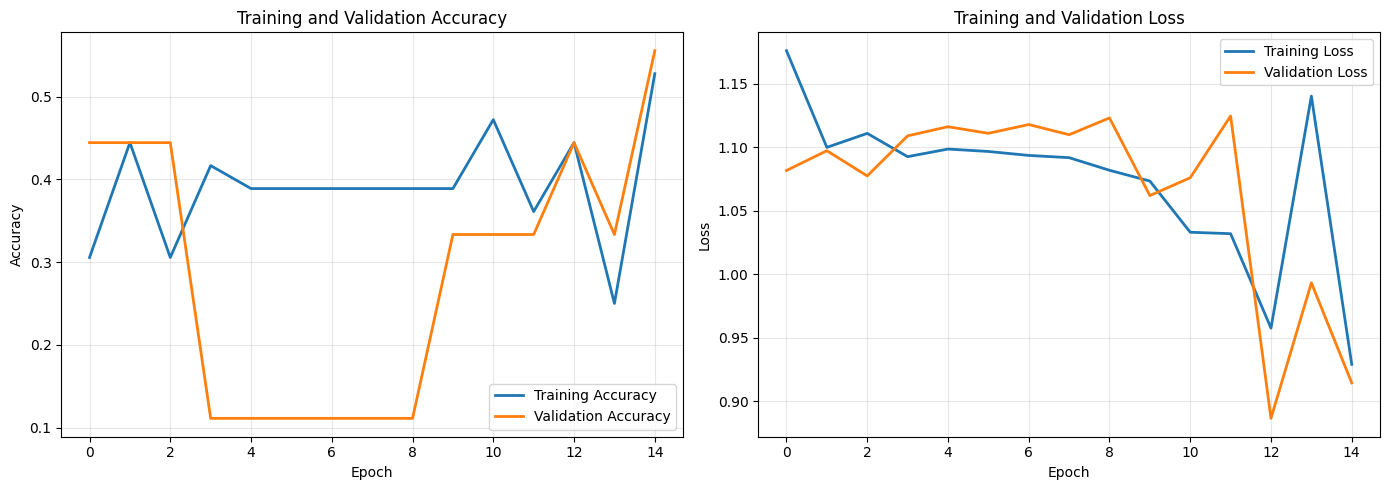

Final Training Accuracy:   52.78%
Final Validation Accuracy: 55.56%


In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_graph.png', dpi=100, bbox_inches='tight')
plt.show()

final_train_acc = acc[-1] * 100
final_val_acc = val_acc[-1] * 100
print(f'Final Training Accuracy:   {final_train_acc:.2f}%')
print(f'Final Validation Accuracy: {final_val_acc:.2f}%')

## Step 8 — Evaluate the model

Generate the full classification report (precision, recall, F1-score) and confusion matrix — the same metrics reported in the paper.

In [12]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get only classes that actually appear in predictions
unique_classes = sorted(set(y_true) | set(y_pred))
present_class_names = [class_names[i] for i in unique_classes]

print('=' * 70)
print('CLASSIFICATION REPORT')
print('=' * 70)
report = classification_report(
    y_true, y_pred,
    labels=unique_classes,
    target_names=present_class_names,
    digits=4
)
print(report)

with open('results/classification_report.txt', 'w') as f:
    f.write('Classification Report\n')
    f.write('=' * 70 + '\n\n')
    f.write(report)
print('Saved: results/classification_report.txt')

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

 water_asphalt_smooth     1.0000    1.0000    1.0000         1
water_concrete_smooth     0.0000    0.0000    0.0000         4
         water_gravel     0.5000    1.0000    0.6667         4

             accuracy                         0.5556         9
            macro avg     0.5000    0.6667    0.5556         9
         weighted avg     0.3333    0.5556    0.4074         9

Saved: results/classification_report.txt


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 9 — Confusion matrix

This visualizes how often each class was predicted correctly vs. confused with another class.

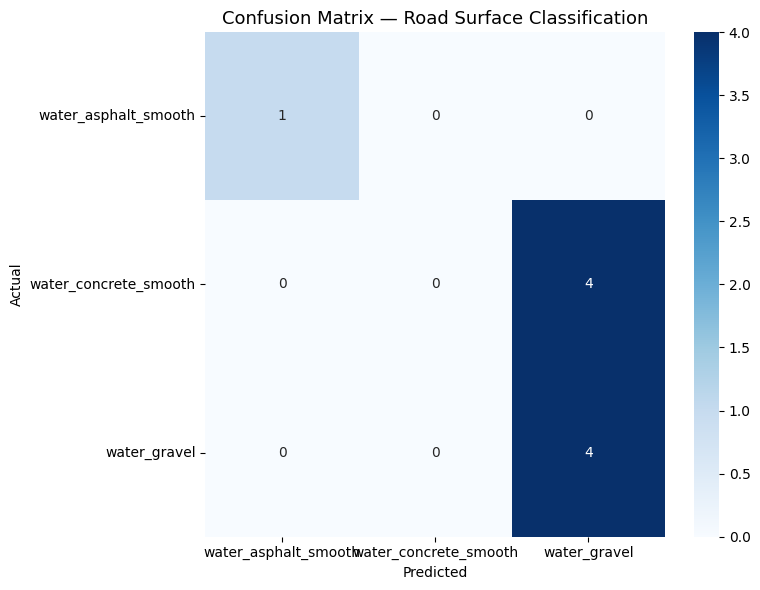

Saved: results/confusion_matrix.png


In [13]:
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_class_names,
            yticklabels=present_class_names)
plt.title('Confusion Matrix — Road Surface Classification', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_matrix.png')

## Step 10 — Visualize sample predictions

Let's see the model making actual predictions on images.

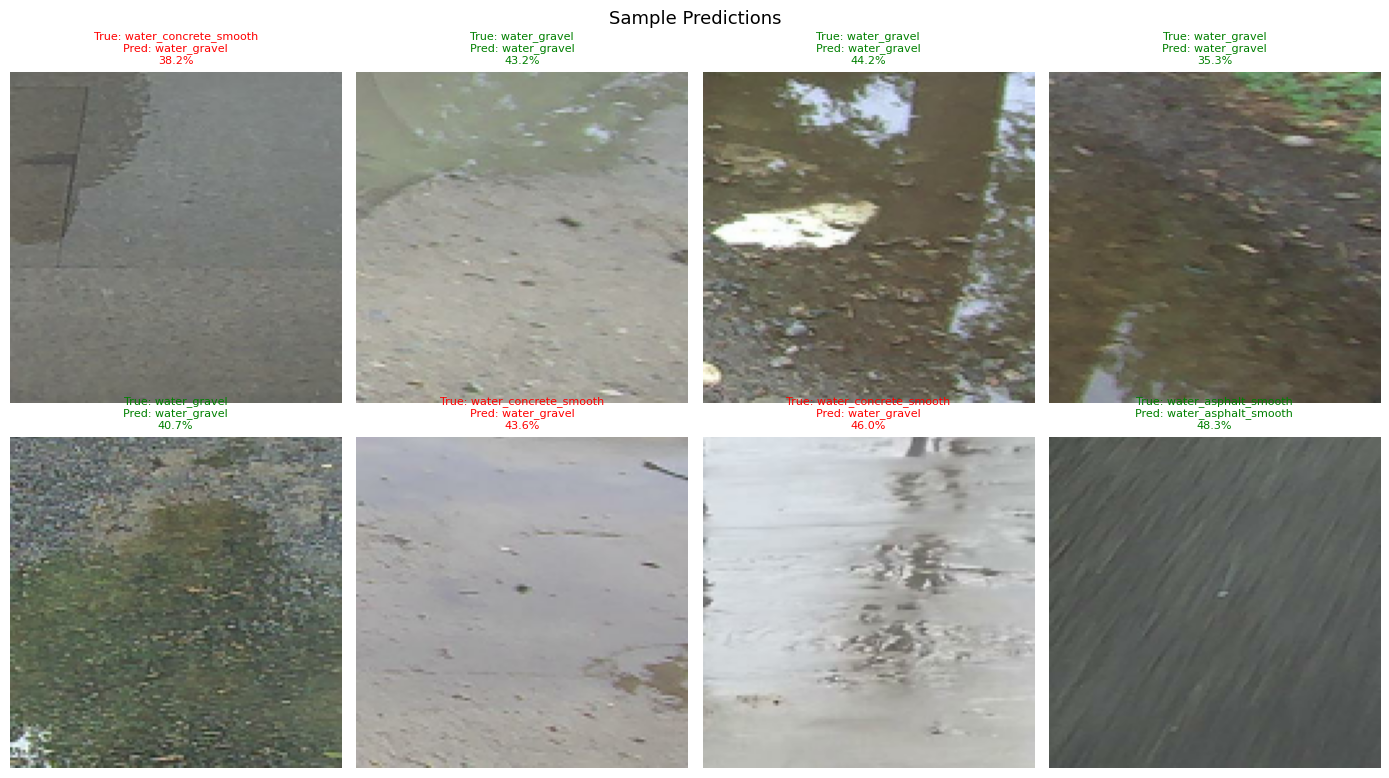

Saved: results/sample_predictions.png


In [14]:
plt.figure(figsize=(14, 8))
for images, labels in val_ds.take(1):
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    confidences = np.max(tf.nn.softmax(predictions).numpy(), axis=1) * 100

    num_show = min(8, len(images))
    for i in range(num_show):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        true_label = class_names[labels[i]]
        pred_label = class_names[predicted_classes[i]]
        conf = confidences[i]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f'True: {true_label}\nPred: {pred_label}\n{conf:.1f}%',
                  color=color, fontsize=8)
        plt.axis('off')

plt.suptitle('Sample Predictions', fontsize=13)
plt.tight_layout()
plt.savefig('results/sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: results/sample_predictions.png')

## Step 12 — Download all results as a zip file

Run this to download everything in one go. The zip file will appear in your browser's downloads.

In [15]:
model.save('results/road_classification_model.keras')
print('Model saved.')

import shutil
from google.colab import files
shutil.make_archive('road_classification_results', 'zip', 'results')
files.download('road_classification_results.zip')
print('Downloaded.')

Model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded.
